# Hierarchical Clustering Analysis

## Objective
This notebook applies Hierarchical Clustering to group similar shipments based on operational and risk-related variables. The goal is to identify natural shipment groupings and compare them with the K-Means clustering results.

## Selected Features
The clustering analysis is based on the following variables:
- Distance_km
- Weight_MT
- Fuel_Price_Index
- Geopolitical_Risk_Score
- Carrier_Reliability_Score
- Lead_Time_Days

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
#Load the cleaned data set
df = pd.read_csv("../data/processed/cleaned_supply_chain_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 18)


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Month_Name,Quarter
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39000,1,2025,10,October,4
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92000,1,2024,4,April,2
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54000,0,2024,1,January,1
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,49.85375,1,2024,10,October,4
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50000,1,2024,9,September,3


In [4]:
#Feature Selection
cluster_features = [
    'Distance_km',
    'Weight_MT',
    'Fuel_Price_Index',
    'Geopolitical_Risk_Score',
    'Carrier_Reliability_Score',
    'Lead_Time_Days'
]

X = df[cluster_features].copy()
X.head()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days
0,5930.83,197.42,2.43,5.0,0.865,41.39000
1,14285.36,237.24,2.30,7.5,0.592,40.92000
2,11113.91,427.42,1.78,5.6,0.673,11.54000
3,9180.55,170.66,3.20,0.8,0.832,49.85375
4,2762.27,434.96,2.77,1.9,0.741,0.50000


In [5]:
#Check for missing values
X.isnull().sum()

Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Carrier_Reliability_Score    0
Lead_Time_Days               0
dtype: int64

In [6]:
#Scaling data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (5000, 6)


## Linkage Method

Ward linkage was selected for Hierarchical Clustering because it minimizes within-cluster variance and is well suited for standardized numerical data. This makes it appropriate for identifying compact operational shipment groups.

In [7]:
#Linkage matrix
linked = linkage(X_scaled, method='ward')


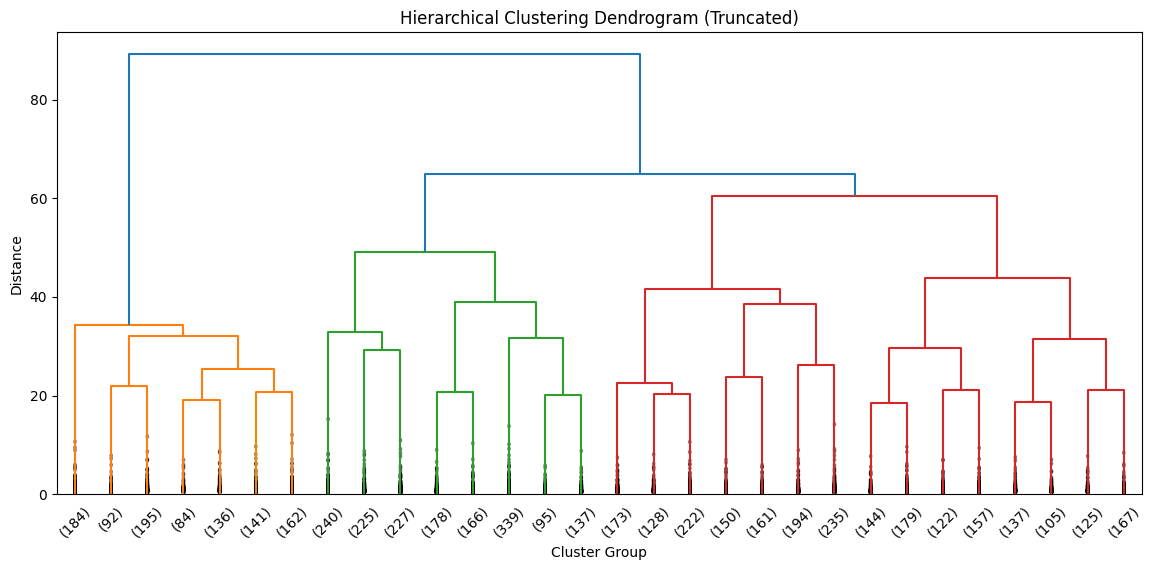

In [8]:
#Ploting the dendrogram
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Cluster Group")
plt.ylabel("Distance")
plt.show()

# Cluster Count Selection

Several cluster counts were evaluated using silhouette scores. This helps identify the number of clusters that provides the best separation and cohesion while remaining interpretable for business analysis.

In [9]:
silhouette_scores = {}

for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores

{2: 0.17611108332804978,
 3: 0.10268616263480132,
 4: 0.0956754071196033,
 5: 0.08751604268204241,
 6: 0.07920764900676368,
 7: 0.07653165445398495,
 8: 0.07366047293086456}

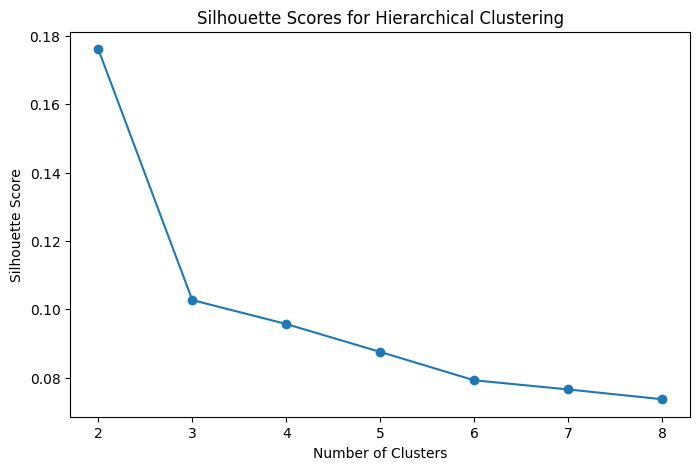

In [10]:
#Visualize silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Hierarchical Clustering")
plt.show()

## Final Cluster Selection

Although the silhouette score was highest at k = 2, 
this configuration produced overly broad clusters that did not provide sufficient granularity for meaningful operational insights.

A cluster count of k = 5 was selected to align with the K-Means clustering results and to enable more detailed segmentation of shipment behavior. 
While the silhouette score for k = 5 is lower, it still provides a reasonable balance between cluster separation and interpretability.

This approach ensures consistency across clustering methods and enhances the practical usefulness of the analysis.

In [12]:
final_k = 5

In [13]:
#Final hierarchical clustering model
hier_model = AgglomerativeClustering(n_clusters=final_k, linkage='ward')
df['Hierarchical_Cluster'] = hier_model.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = df['Hierarchical_Cluster'].astype(int)
df[['Hierarchical_Cluster'] + cluster_features].head()

,Hierarchical_Cluster,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days
0,3,5930.83,197.42,2.43,5.0,0.865,41.39000
1,3,14285.36,237.24,2.30,7.5,0.592,40.92000
2,2,11113.91,427.42,1.78,5.6,0.673,11.54000
3,3,9180.55,170.66,3.20,0.8,0.832,49.85375
4,1,2762.27,434.96,2.77,1.9,0.741,0.50000


In [14]:
#Cluster distribution
df['Hierarchical_Cluster'].value_counts().sort_index()

Hierarchical_Cluster
0    1136
1    1263
2     915
3     994
4     692
Name: count, dtype: int64

All 5 clusters are reasonably balanced

In [15]:
#Cluster summary table
cluster_summary = df.groupby('Hierarchical_Cluster').agg({
    'Distance_km': 'mean',
    'Weight_MT': 'mean',
    'Fuel_Price_Index': 'mean',
    'Geopolitical_Risk_Score': 'mean',
    'Carrier_Reliability_Score': 'mean',
    'Lead_Time_Days': 'mean',
    'Disruption_Occurred': 'mean'
}).round(2)

cluster_summary['Disruption_Occurred'] = cluster_summary['Disruption_Occurred'] * 100
cluster_summary = cluster_summary.rename(columns={'Disruption_Occurred': 'Disruption_Rate_%'})

cluster_summary

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Rate_%
Hierarchical_Cluster,,,,,,,
0,7429.02,279.45,2.07,5.07,0.86,8.80,52.0
1,5984.20,257.17,3.68,4.92,0.82,7.05,53.0
2,4924.86,211.77,2.46,4.92,0.63,6.20,58.0
3,10216.01,248.07,2.83,5.72,0.74,41.07,90.0
4,11361.19,214.83,3.20,4.67,0.64,11.00,55.0


# Cluster Interpretation

The hierarchical clustering analysis identified five distinct shipment groups based on operational and risk related characteristics.

# Cluster 0 – Moderate Distance, Stable Performance
- Moderate distance and weight
- Low fuel price index
- Average geopolitical risk
- High carrier reliability
- Moderate lead time (~9 days)
- Moderate disruption rate (~52%)

This cluster represents relatively stable and efficient shipments with balanced operational conditions.



# Cluster 1 – Short Distance, Efficient Operations
- Shorter distances compared to others
- Moderate weight
- High fuel price index
- Low-to-moderate risk
- Good carrier reliability
- Lower lead time (~7 days)
- Moderate disruption rate (~53%)

This cluster indicates efficient logistics operations with faster delivery and relatively controlled risk levels.



# Cluster 2 – Low Reliability, Higher Disruption Risk
- Short-to-moderate distance
- Lower weight
- Moderate fuel prices
- Moderate risk levels
- Low carrier reliability
- Low lead time (~6 days)
- Higher disruption rate (~58%)

Despite shorter lead times, this cluster shows weaker reliability and increased disruption risk, suggesting operational inefficiencies.



# Cluster 3 – High-Risk, Highly Disrupted Shipments
- Long distances
- Moderate weight
- Moderate fuel price index
- Highest geopolitical risk
- Lower carrier reliability
- Extremely high lead time (~41 days)
- Very high disruption rate (~90%)

This cluster represents high risk shipments with severe delays and frequent disruptions, likely due to external risk factors and operational challenges.



# Cluster 4 – Long Distance, Moderate Risk
- Longest distances
- Lower weight
- Higher fuel price index
- Moderate risk levels
- Low carrier reliability
- Moderate lead time (~11 days)
- Moderate disruption rate (~55%)

This cluster reflects long distance shipments with moderate performance but potential reliability concerns.



# Summary

Overall, the clustering results reveal clear segmentation of shipment operations into efficient, moderate, and high-risk groups. 
In particular, Cluster 3 highlights critical operational inefficiencies and disruption prone shipments, which may require strategic intervention and risk mitigation.

In [16]:
#PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

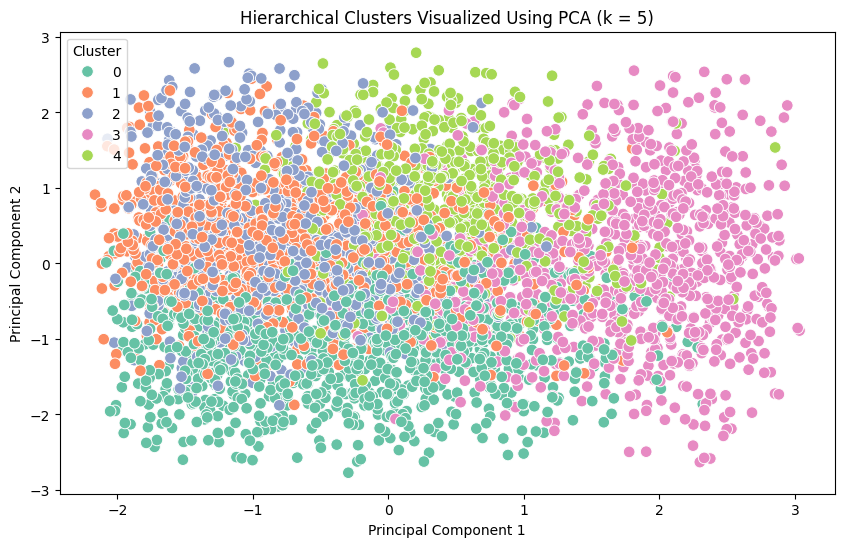

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Hierarchical_Cluster',
    palette='Set2',
    s=70
)
plt.title(f"Hierarchical Clusters Visualized Using PCA (k = {final_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

## PCA Cluster Visualization

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset and visualize the hierarchical clustering results in two dimensions.

The visualization shows partial separation/ overlapping among several clusters. 
It indicates that shipment characteristics are not entirely distinct and may share common operational patterns.

Meanwhile Cluster 3 appears more clearly separated from the others, 
suggesting that it represents a distinct group of high risk shipments with significantly different operational characteristics.

Overall, the PCA visualization supports the validity of the clustering results while highlighting the inherent complexity and overlap in real world supply chain data.

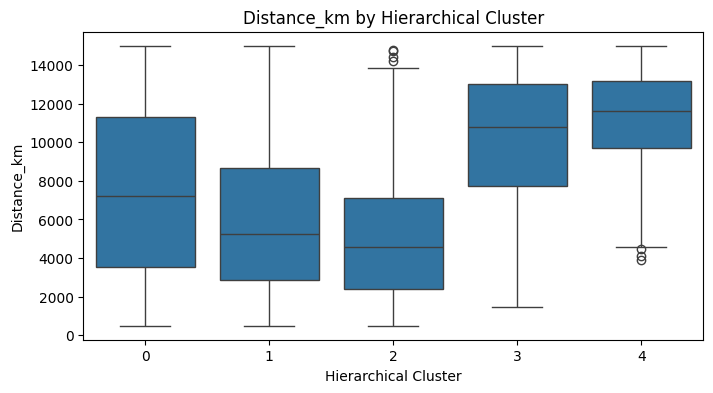

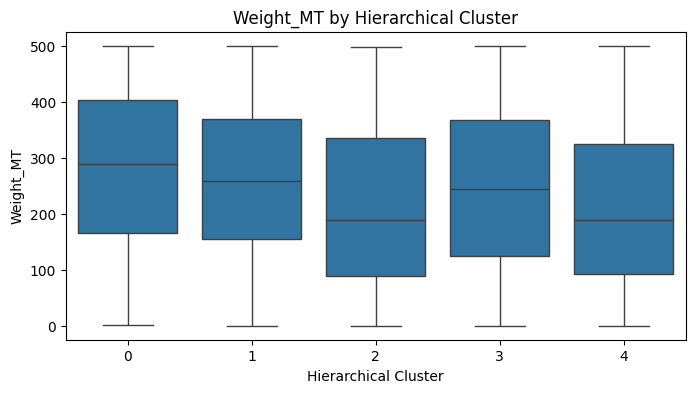

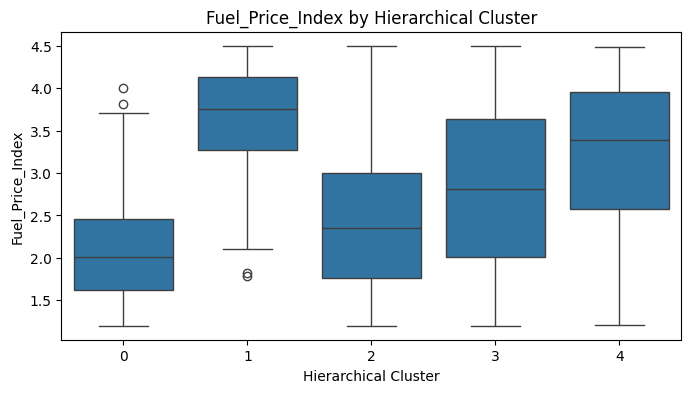

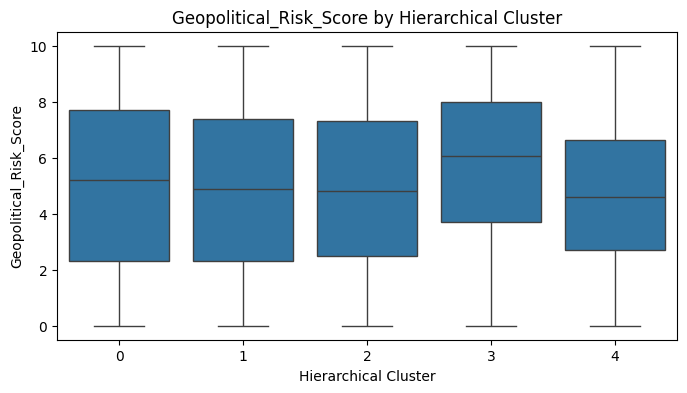

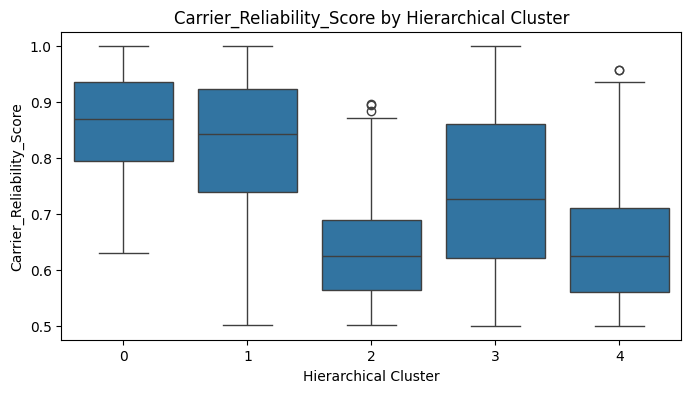

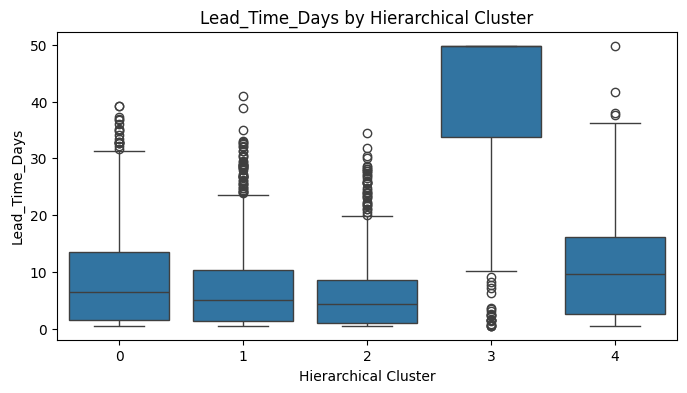

In [19]:
#Feature comparison across cluster
for col in cluster_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Hierarchical_Cluster', y=col)
    plt.title(f"{col} by Hierarchical Cluster")
    plt.xlabel("Hierarchical Cluster")
    plt.ylabel(col)
    plt.show()

## Feature wise Cluster Comparison

Boxplot analysis was conducted to compare the distribution of key variables across hierarchical clusters. 
This helps identify the main factors that differentiate shipment groups.

# Distance_km
Clusters 3 and 4 show significantly higher distances compared to other clusters, indicating long haul shipments. 
Clusters 1 and 2 consist of shorter distance shipments, suggesting more localized logistics operations.



# Weight_MT
Cluster 0 has relatively higher shipment weights, while Cluster 2 and Cluster 4 tend to have lower weights. 
This indicates that heavier shipments are more concentrated in specific operational groups.



# Fuel_Price_Index
Cluster 1 and Cluster 4 are associated with higher fuel price indices, suggesting that these shipments may be more sensitive to fuel cost fluctuations. 
Cluster 0 has the lowest fuel price exposure.



# Geopolitical_Risk_Score
Cluster 3 exhibits the highest geopolitical risk levels, confirming that it represents high risk shipments. 
Other clusters show moderate and relatively similar risk distributions.



# Carrier_Reliability_Score
Clusters 0 and 1 demonstrate higher carrier reliability, indicating more stable logistics performance. 
Clusters 2 and 4 have lower reliability scores, suggesting weaker operational efficiency.



# Lead_Time_Days
Cluster 3 stands out with significantly higher lead times compared to all other clusters, confirming severe delays. 
Clusters 0, 1, and 2 show relatively low lead times, indicating faster shipment performance.



# Summary

The feature wise comparison highlights that:
- Distance and lead time are key differentiators between clusters
- Cluster 3 is clearly the most problematic group, with high risk, long distances, and severe delays
- Clusters 0 and 1 represent more efficient and reliable shipment groups
- Clusters 2 and 4 show moderate performance with specific operational weaknesses

These findings support the validity of the clustering model and provide actionable insights into shipment performance segmentation.

#Business level categorical analysis

In [20]:
#Transport Mode by cluster
transport_cluster = pd.crosstab(
    df['Hierarchical_Cluster'],
    df['Transport_Mode'],
    normalize='index'
) * 100

transport_cluster.round(2)

Transport_Mode,Air,Rail,Road,Sea
Hierarchical_Cluster,,,,
0,31.60,23.94,25.26,19.19
1,31.12,22.01,25.65,21.22
2,31.69,21.20,26.23,20.87
3,2.11,25.96,21.53,50.40
4,37.14,26.45,21.53,14.88


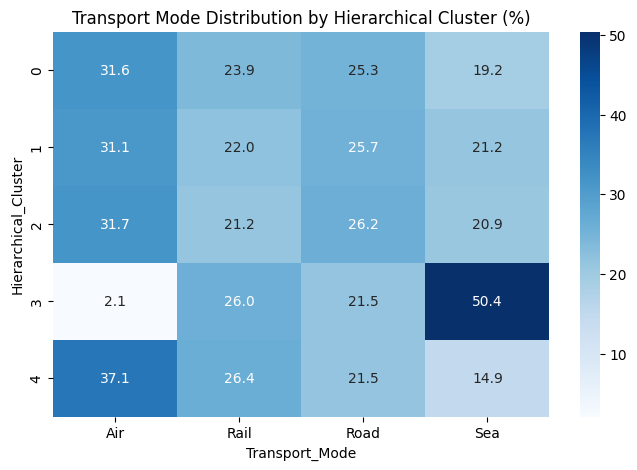

In [21]:
plt.figure(figsize=(8, 5))
sns.heatmap(transport_cluster, annot=True, fmt=".1f", cmap="Blues")
plt.title("Transport Mode Distribution by Hierarchical Cluster (%)")
plt.show()

In [22]:
#Weather Condition by cluster
weather_cluster = pd.crosstab(
    df['Hierarchical_Cluster'],
    df['Weather_Condition'],
    normalize='index'
) * 100

weather_cluster.round(2)

Weather_Condition,Clear,Fog,Hurricane,Rain,Storm
Hierarchical_Cluster,,,,,
0,24.21,23.86,10.48,23.42,18.05
1,23.59,23.99,9.82,23.12,19.48
2,23.50,22.73,11.80,21.53,20.44
3,3.62,8.95,57.44,3.92,26.06
4,24.71,23.84,9.83,26.45,15.17


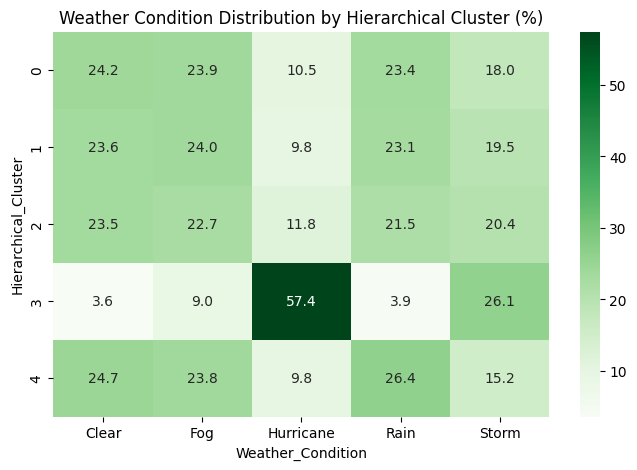

In [23]:
plt.figure(figsize=(8, 5))
sns.heatmap(weather_cluster, annot=True, fmt=".1f", cmap="Greens")
plt.title("Weather Condition Distribution by Hierarchical Cluster (%)")
plt.show()

In [24]:
#Product Category by cluster
product_cluster = pd.crosstab(
    df['Hierarchical_Cluster'],
    df['Product_Category'],
    normalize='index'
) * 100

product_cluster.round(2)

Product_Category,Automotive,Electronics,Perishables,Pharmaceuticals,Textiles
Hierarchical_Cluster,,,,,
0,18.84,22.18,20.25,18.84,19.89
1,20.19,21.54,19.32,20.19,18.76
2,18.80,19.23,20.66,20.22,21.09
3,18.21,17.91,20.22,21.03,22.64
4,19.80,19.94,20.95,20.66,18.64


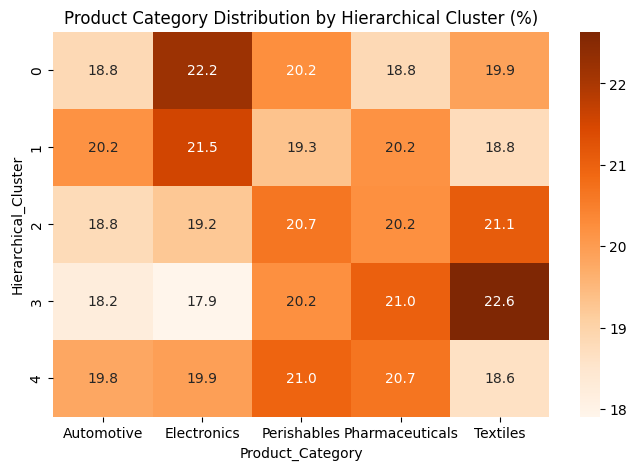

In [25]:
plt.figure(figsize=(8, 5))
sns.heatmap(product_cluster, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Product Category Distribution by Hierarchical Cluster (%)")
plt.show()

In [26]:
#Saving outputs
cluster_summary.to_csv("../data/processed/hierarchical_cluster_summary.csv")
transport_cluster.round(2).to_csv("../data/processed/hierarchical_transport_by_cluster.csv")
weather_cluster.round(2).to_csv("../data/processed/hierarchical_weather_by_cluster.csv")
product_cluster.round(2).to_csv("../data/processed/hierarchical_product_by_cluster.csv")
df.to_csv("../data/processed/hierarchical_clustered_data.csv", index=False)

# Conclusion

Hierarchical Clustering was applied to identify natural shipment groupings using key operational and risk-related variables. 
After preprocessing and scaling, five meaningful clusters were identified, representing distinct shipment behaviors and performance patterns.

The analysis revealed clear segmentation across multiple dimensions:

- Cluster 3 emerged as the most critical group, characterized by high geopolitical risk, low carrier reliability, extremely long lead times, and a very high disruption rate. 
This cluster is strongly associated with sea transport and extreme weather conditions such as hurricanes, indicating vulnerability to external disruptions.

- Clusters 0 and 1 represent relatively efficient and stable shipment operations, with shorter lead times, higher carrier reliability, and moderate disruption rates. 
These clusters are more evenly distributed across transport modes and weather conditions.

- Cluster 2 shows moderate operational performance but lower reliability, suggesting potential inefficiencies despite shorter delivery times.

- Cluster 4 represents long distance shipments with moderate disruption risk, indicating that distance alone does not necessarily lead to severe operational issues, but reliability remains a concern.

The categorical analysis further highlights that:
- Sea transport is strongly linked to high risk and high delay clusters
- Extreme weather conditions significantly impact disruption prone shipments
- Product categories are relatively evenly distributed, suggesting that operational risk is more influenced by logistics and environmental factors than by product type

Overall, the clustering results provide actionable insights into supply chain performance, enabling identification of high risk shipment groups and supporting targeted strategies for risk mitigation, route optimization, and improved operational efficiency.